<div align="center">
    <h1>NYC Trip Duration Prediction</h1>
</div>

#### This is a Predictive Modelling file building on the conclusion made in EDA file of the project 

* **id** - a unique identifier for each trip
* **vendor_id** - a code indicating the provider associated with the trip record
* **pickup_datetime** - date and time when the meter was engaged
* **dropoff_datetime** - date and time when the meter was disengaged
* **passenger_count** - the number of passengers in the vehicle (driver entered value)
* **pickup_longitude** - the longitude where the meter was engaged
* **pickup_latitude** - the latitude where the meter was engaged
* **dropoff_longitude** - the longitude where the meter was disengaged
* **dropoff_latitude** - the latitude where the meter was disengaged
* **store_and_fwd_flag** - This flag indicates whether the trip record was held in vehicle memory before sending to the vendor because the vehicle did not have a connection to the server (Y=store and forward; N=not a store and forward trip)
* **trip_duration** - (target) duration of the trip in seconds

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [58]:
data = pd.read_pickle('NYC_trip_duration_prediction.pickle')

In [59]:
data.head()

,id,vendor_id,passenger_count,store_and_fwd_flag,pickup_dow,pickup_moy,pickup_hour,dropoff_dow,dropoff_moy,dropoff_hour,pickup_time_of_day,dropoff_time_of_day,distance,speed,trip_duration
0,id1080784,2,1,N,Monday,2,16,Monday,2,16,Evening,Evening,1.199770,10.797929,6.666667
1,id0889885,1,2,N,Friday,3,23,Friday,3,23,Late night,Late night,4.123945,13.496548,18.333333
2,id0857912,2,2,N,Sunday,2,17,Sunday,2,18,Evening,Evening,7.250436,15.964262,27.250000
3,id3744273,2,6,N,Tuesday,1,9,Tuesday,1,10,Morning,Morning,2.358287,7.440694,19.016667
4,id0232939,1,1,N,Wednesday,2,6,Wednesday,2,6,Morning,Morning,4.328155,18.374244,14.133333


* The feature id is unique for each observation and hence can not be used to build the model.
* The features such as pickup_time_of_day and dropoff_time_of_day are derived from pickup and dropoff hours and can create multicollinearity in the model.
* The feature speed is also derived from trip duration and distance so we dropped it from model building procedure. 

In [60]:
data.drop(['id','speed','pickup_time_of_day','dropoff_time_of_day'],axis=1,inplace=True)

### Data Preprocessing  

In [61]:
data.isnull().sum()

vendor_id             0
passenger_count       0
store_and_fwd_flag    0
pickup_dow            0
pickup_moy            0
pickup_hour           0
dropoff_dow           0
dropoff_moy           0
dropoff_hour          0
distance              0
trip_duration         0
dtype: int64

* Data does not have any null values. 

In [62]:
data.dtypes

vendor_id             category
passenger_count          int64
store_and_fwd_flag    category
pickup_dow            category
pickup_moy               int64
pickup_hour              int64
dropoff_dow           category
dropoff_moy              int64
dropoff_hour             int64
distance               float64
trip_duration          float64
dtype: object

* Distance and Trip duration are only two continuous features in the data. Let us check their distribution.

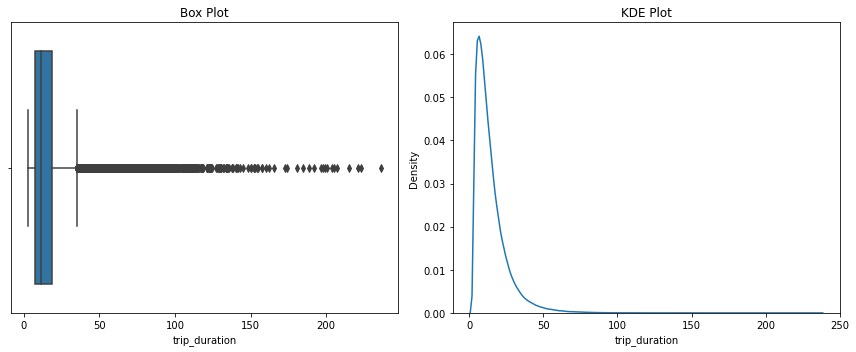

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x=data['trip_duration'], ax=axes[0])
axes[0].set_title('Box Plot')
sns.kdeplot(data['trip_duration'], ax=axes[1])
axes[1].set_title('KDE Plot')

plt.tight_layout()

# Show the plots
plt.show()

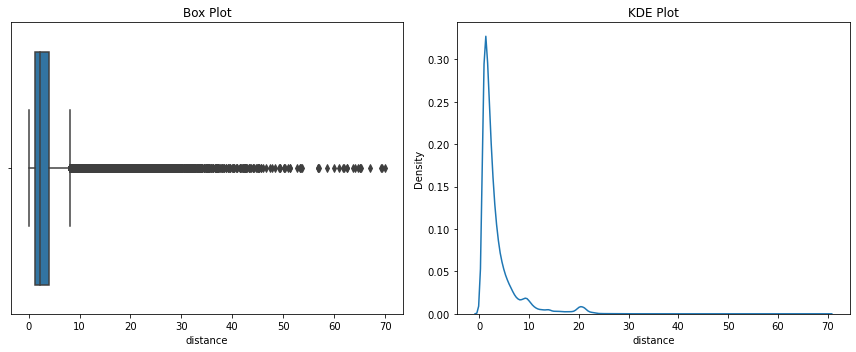

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x=data['distance'], ax=axes[0])
axes[0].set_title('Box Plot')
sns.kdeplot(data['distance'], ax=axes[1])
axes[1].set_title('KDE Plot')

plt.tight_layout()

# Show the plots
plt.show()

In [9]:
654819/729322*100

89.78462188169286

* We have some outliers in the data and the distribution is rightly skewed.
* After removing absurdly high or low values from distance and trip duration features in EDA we are left with 89.7% of the data.

* Let's consider data points within the whiskers of boxplot for distance and and trip duration.

In [40]:
Q1 = data['trip_duration'].quantile(0.25)
Q3 = data['trip_duration'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1-1.5*IQR
upper = Q3+1.5*IQR
data1 = data[(data['trip_duration'] >= lower) & (data['trip_duration'] <= upper)]

C:\Users\user\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='trip_duration'>

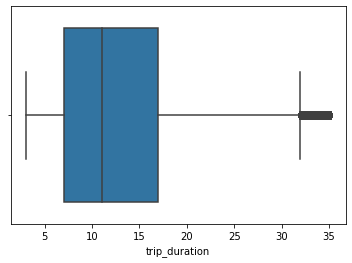

In [41]:
sns.boxplot(data1['trip_duration'])

In [42]:
Q1 = data1['distance'].quantile(0.25)
Q3 = data1['distance'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1-1.5*IQR
upper = Q3+1.5*IQR
data2 = data1[(data1['distance'] >= lower) & (data1['distance'] <= upper)]

C:\Users\user\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='distance'>

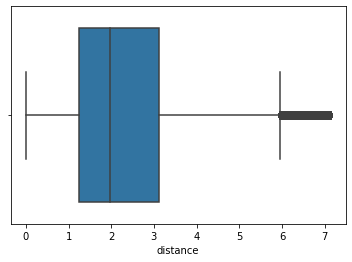

In [43]:
sns.boxplot(data2['distance'])

In [44]:
data2.shape

(603542, 11)

In [15]:
(614608/729322)*100

84.27114498122914

* After considering data points within the whiskers we are left with 84% of the original data.

In [65]:
data.head()

,vendor_id,passenger_count,store_and_fwd_flag,pickup_dow,pickup_moy,pickup_hour,dropoff_dow,dropoff_moy,dropoff_hour,distance,trip_duration
0,2,1,N,Monday,2,16,Monday,2,16,1.199770,6.666667
1,1,2,N,Friday,3,23,Friday,3,23,4.123945,18.333333
2,2,2,N,Sunday,2,17,Sunday,2,18,7.250436,27.250000
3,2,6,N,Tuesday,1,9,Tuesday,1,10,2.358287,19.016667
4,1,1,N,Wednesday,2,6,Wednesday,2,6,4.328155,14.133333


### 1. Benchmark Model: Linear Regression

* For the benchmark model let us consider only one feature i.e. Distance as X and trip duration and y

In [66]:
Benchmark = data.drop(['dropoff_dow','dropoff_moy','dropoff_hour'],axis=1)

In [67]:
Benchmark

,vendor_id,passenger_count,store_and_fwd_flag,pickup_dow,pickup_moy,pickup_hour,distance,trip_duration
0,2,1,N,Monday,2,16,1.199770,6.666667
1,1,2,N,Friday,3,23,4.123945,18.333333
2,2,2,N,Sunday,2,17,7.250436,27.250000
3,2,6,N,Tuesday,1,9,2.358287,19.016667
4,1,1,N,Wednesday,2,6,4.328155,14.133333
...,...,...,...,...,...,...,...,...
729317,2,2,N,Saturday,5,13,1.123068,4.933333
729318,1,1,N,Monday,2,0,0.728563,5.250000
729319,1,1,N,Friday,4,18,2.295919,11.216667
729320,1,1,N,Sunday,6,9,0.846722,7.450000


* Train Test Split 

In [68]:
X = Benchmark['distance']
y = Benchmark['trip_duration']

In [69]:
from sklearn.model_selection import train_test_split

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

* Fitting Linear Regression Model

In [71]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [72]:
X_train = X_train.values.reshape(-1, 1)

In [73]:
X_test = X_test.values.reshape(-1,1)

In [74]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

linear_model = LinearRegression()
Benchmark_model = linear_model.fit(X_train, y_train)

# Make predictions
Benchmark_train_predictions = Benchmark_model.predict(X_train)
Benchmark_test_predictions = Benchmark_model.predict(X_test)
mse = mean_squared_error(y_test, Benchmark_test_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, Benchmark_test_predictions)

print(f"Benchmark Root Mean Squared Error: {rmse}")
print(f"Benchmark R-squared: {r2}")

Benchmark Root Mean Squared Error: 7.079665019198242
Benchmark R-squared: 0.5783058532611671


### Let us Compare this Benchmark Model with other more complex models.

* Linear Regression Model:
  * Consider all the features from the data.
  * Considered all the data not just within the boxplots whiskers of distance and trip_duration
  * Scale the data.
  * Fit the model.

### 2. Linear Regression Model

In [75]:
data.head()

,vendor_id,passenger_count,store_and_fwd_flag,pickup_dow,pickup_moy,pickup_hour,dropoff_dow,dropoff_moy,dropoff_hour,distance,trip_duration
0,2,1,N,Monday,2,16,Monday,2,16,1.199770,6.666667
1,1,2,N,Friday,3,23,Friday,3,23,4.123945,18.333333
2,2,2,N,Sunday,2,17,Sunday,2,18,7.250436,27.250000
3,2,6,N,Tuesday,1,9,Tuesday,1,10,2.358287,19.016667
4,1,1,N,Wednesday,2,6,Wednesday,2,6,4.328155,14.133333


In [76]:
data['store_and_fwd_flag'].value_counts(normalize=True)

N    0.99445
Y    0.00555
Name: store_and_fwd_flag, dtype: float64

* store_and_fwd_flag lacks variability in the data so we'll drop it.

In [77]:
data.drop('store_and_fwd_flag',axis=1,inplace=True)

* One-hot Encoding

In [78]:
df_lr = pd.get_dummies(data=data, columns=['pickup_dow','dropoff_dow'], drop_first=True)

* Scaling the data

In [79]:
X = df_lr.drop('trip_duration',axis=1)
y = df_lr['trip_duration']

In [80]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaledX = scaler.fit_transform(X)

In [81]:
scaledX = pd.DataFrame(scaledX,columns=X.columns)

In [82]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42)

In [84]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

linear_model = LinearRegression()
lr_model = linear_model.fit(X_train, y_train)

# Make predictions
lr_train_predictions = lr_model.predict(X_train)
lr_test_predictions = lr_model.predict(X_valid)

mse = mean_squared_error(y_valid, lr_test_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_valid, lr_test_predictions)

print(f"Benchmark Root Mean Squared Error: {rmse}")
print(f"Benchmark R-squared: {r2}")

Benchmark Root Mean Squared Error: 6.955456426292884
Benchmark R-squared: 0.59297280866459


* Let us remove some features which might be creating multicollinearity in the data

In [85]:
correlation_matrix = df_lr.corr()

<AxesSubplot:>

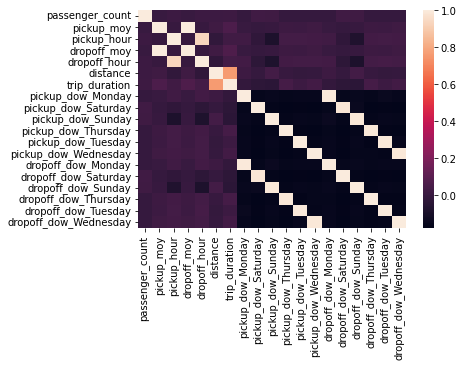

In [86]:
sns.heatmap(correlation_matrix)

* Here pickup_dow and dropoff_dow are same for majority of the cases which are creating collinearity.

In [87]:
LR_data = data.drop(['dropoff_dow','dropoff_moy','dropoff_hour'],axis=1)

In [88]:
df_lr = pd.get_dummies(data=LR_data, columns=['pickup_dow'], drop_first=True)
df_lr

,vendor_id,passenger_count,pickup_moy,pickup_hour,distance,trip_duration,pickup_dow_Monday,pickup_dow_Saturday,pickup_dow_Sunday,pickup_dow_Thursday,pickup_dow_Tuesday,pickup_dow_Wednesday
0,2,1,2,16,1.199770,6.666667,1,0,0,0,0,0
1,1,2,3,23,4.123945,18.333333,0,0,0,0,0,0
2,2,2,2,17,7.250436,27.250000,0,0,1,0,0,0
3,2,6,1,9,2.358287,19.016667,0,0,0,0,1,0
4,1,1,2,6,4.328155,14.133333,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
729317,2,2,5,13,1.123068,4.933333,0,1,0,0,0,0
729318,1,1,2,0,0.728563,5.250000,1,0,0,0,0,0
729319,1,1,4,18,2.295919,11.216667,0,0,0,0,0,0
729320,1,1,6,9,0.846722,7.450000,0,0,1,0,0,0


In [89]:
X = df_lr.drop('trip_duration',axis=1)
y = df_lr['trip_duration']

In [90]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaledX = scaler.fit_transform(X)
scaledX = pd.DataFrame(scaledX,columns=X.columns)

In [91]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42)

In [92]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

linear_model = LinearRegression()
lr_model = linear_model.fit(X_train, y_train)

# Make predictions
lr_train_predictions = lr_model.predict(X_train)
lr_test_predictions = lr_model.predict(X_valid)

mse = mean_squared_error(y_valid, lr_test_predictions)
lr_error = np.sqrt(mse)
r2 = r2_score(y_valid, lr_test_predictions)

print(f"LR Root Mean Squared Error: {rmse}")
print(f"LR R-squared: {r2}")

LR Root Mean Squared Error: 6.955456426292884
LR R-squared: 0.5905604705970446


* This has slightly improved the model. Now let us consider data points within the whiskers to see if model performance improves. 

#### Checking Linear Regression Assumptions

In [93]:
# Arranging and calculating the Residuals
residuals = pd.DataFrame({
    'fitted values' : y_valid,
    'predicted values' : lr_test_predictions,
})

residuals['residuals'] = residuals['fitted values'] - residuals['predicted values']
residuals.head()

,fitted values,predicted values,residuals
29732,17.633333,10.522339,7.110994
501795,28.233333,20.736357,7.496976
23714,11.566667,15.445289,-3.878622
196520,5.283333,9.878174,-4.594840
348357,4.866667,9.735109,-4.868443


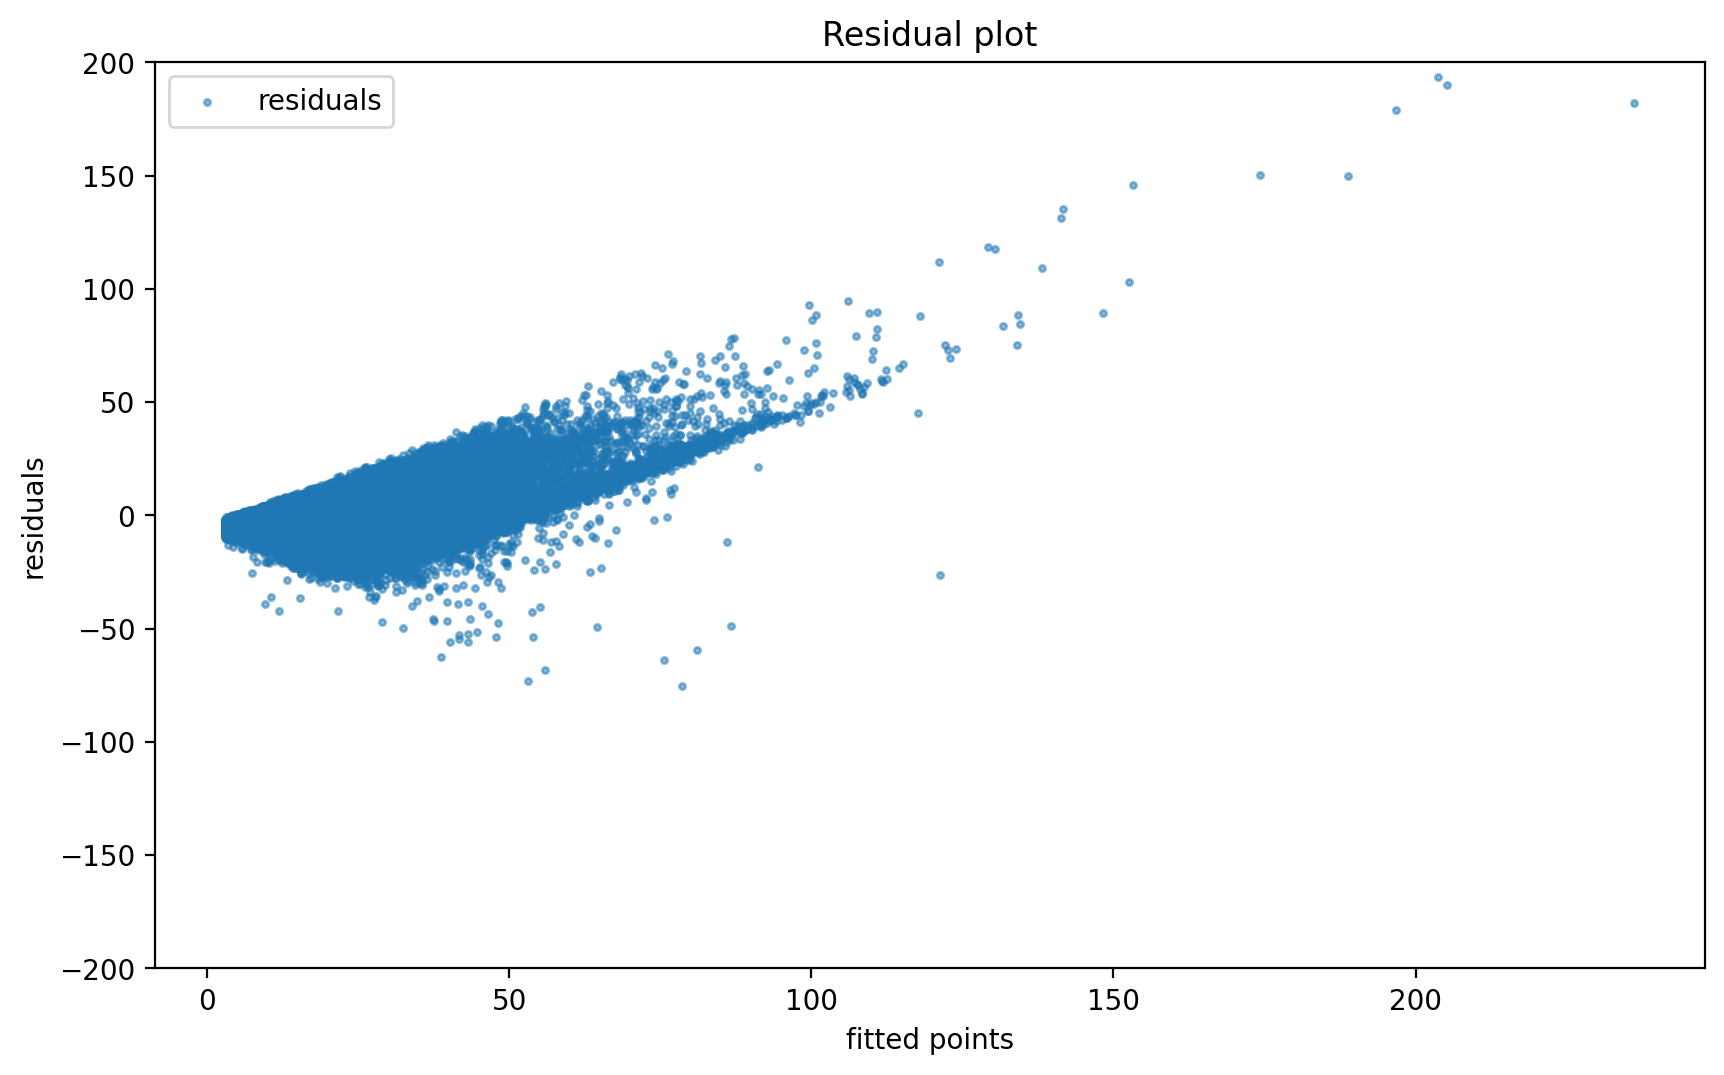

In [94]:
plt.figure(figsize=(10, 6), dpi=200, facecolor='w', edgecolor='b')

# Adjust marker size and use transparency
plt.scatter(residuals['fitted values'], residuals['residuals'], label='residuals', s=5, alpha=0.5)

plt.xlabel('fitted points')
plt.ylabel('residuals')
plt.title('Residual plot')
plt.ylim(-200, 200)
plt.legend()
plt.show()

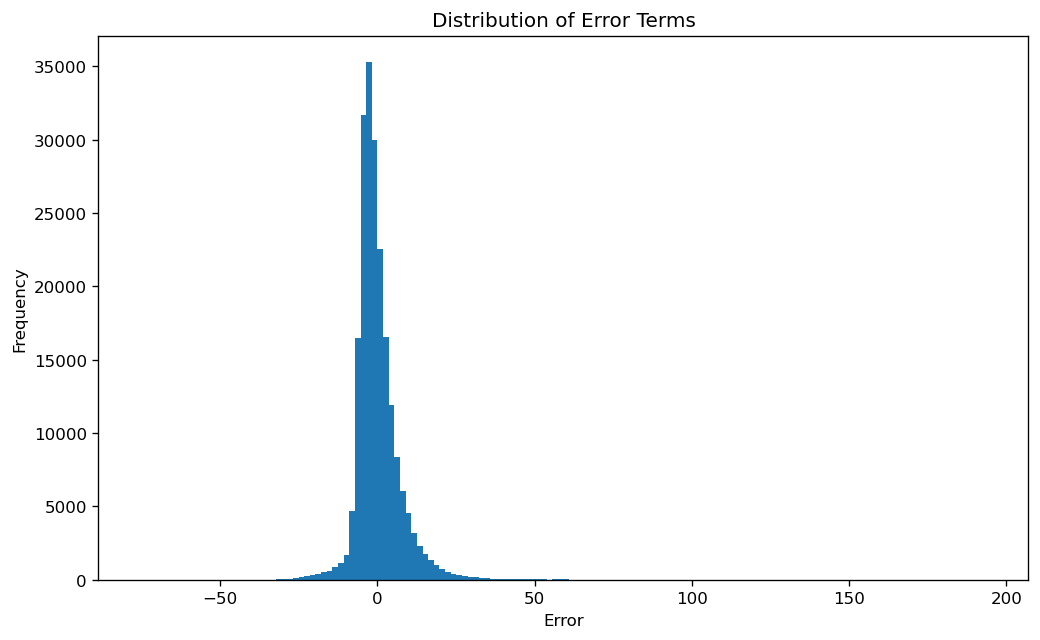

In [95]:
# Histogram for distribution
plt.figure(figsize=(10, 6), dpi=120, facecolor='w', edgecolor='b')
plt.hist(residuals['residuals'], bins = 150)
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.title('Distribution of Error Terms')
plt.show()

C:\Users\user\anaconda3\lib\site-packages\statsmodels\graphics\gofplots.py:993: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bo" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


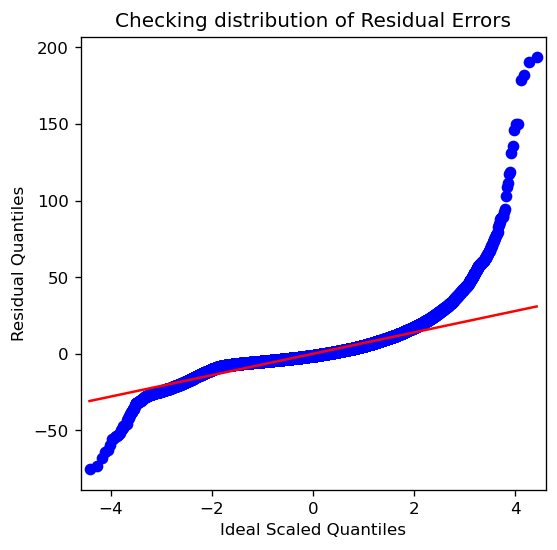

In [96]:
# importing the QQ-plot from the from the statsmodels
from statsmodels.graphics.gofplots import qqplot

## Plotting the QQ plot
fig, ax = plt.subplots(figsize=(5,5) , dpi = 120)
qqplot(residuals.residuals, line = 's' , ax = ax)
plt.ylabel('Residual Quantiles')
plt.xlabel('Ideal Scaled Quantiles')
plt.title('Checking distribution of Residual Errors')
plt.show()

In [97]:
# Importing Variance_inflation_Factor funtion from the Statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Calculating VIF for every column (only works for the not Catagorical)
VIF = pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])], index =X.columns)
VIF

vendor_id               7.852027
passenger_count         2.824858
pickup_moy              4.516848
pickup_hour             4.619750
distance                1.763800
pickup_dow_Monday       1.643023
pickup_dow_Saturday     1.729184
pickup_dow_Sunday       1.634757
pickup_dow_Thursday     1.757548
pickup_dow_Tuesday      1.700758
pickup_dow_Wednesday    1.727498
dtype: float64

### Linear Regression model with data within boxplot

In [45]:
data2

,vendor_id,passenger_count,store_and_fwd_flag,pickup_dow,pickup_moy,pickup_hour,dropoff_dow,dropoff_moy,dropoff_hour,distance,trip_duration
0,2,1,N,Monday,2,16,Monday,2,16,1.199770,6.666667
1,1,2,N,Friday,3,23,Friday,3,23,4.123945,18.333333
3,2,6,N,Tuesday,1,9,Tuesday,1,10,2.358287,19.016667
4,1,1,N,Wednesday,2,6,Wednesday,2,6,4.328155,14.133333
5,2,2,N,Sunday,2,18,Sunday,2,18,3.115642,24.250000
...,...,...,...,...,...,...,...,...,...,...,...
729317,2,2,N,Saturday,5,13,Saturday,5,13,1.123068,4.933333
729318,1,1,N,Monday,2,0,Monday,2,0,0.728563,5.250000
729319,1,1,N,Friday,4,18,Friday,4,19,2.295919,11.216667
729320,1,1,N,Sunday,6,9,Sunday,6,9,0.846722,7.450000


In [17]:
614608/729322*100

84.27114498122914

In [48]:
df = data2.drop(['dropoff_dow','dropoff_moy','dropoff_hour','store_and_fwd_flag'],axis=1,inplace=True)

C:\Users\user\anaconda3\lib\site-packages\pandas\core\frame.py:4906: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(


In [19]:
df

In [49]:
df = pd.get_dummies(data=data2, columns=['pickup_dow'], drop_first=True)
df

,vendor_id,passenger_count,pickup_moy,pickup_hour,distance,trip_duration,pickup_dow_Monday,pickup_dow_Saturday,pickup_dow_Sunday,pickup_dow_Thursday,pickup_dow_Tuesday,pickup_dow_Wednesday
0,2,1,2,16,1.199770,6.666667,1,0,0,0,0,0
1,1,2,3,23,4.123945,18.333333,0,0,0,0,0,0
3,2,6,1,9,2.358287,19.016667,0,0,0,0,1,0
4,1,1,2,6,4.328155,14.133333,0,0,0,0,0,1
5,2,2,2,18,3.115642,24.250000,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
729317,2,2,5,13,1.123068,4.933333,0,1,0,0,0,0
729318,1,1,2,0,0.728563,5.250000,1,0,0,0,0,0
729319,1,1,4,18,2.295919,11.216667,0,0,0,0,0,0
729320,1,1,6,9,0.846722,7.450000,0,0,1,0,0,0


In [50]:
X = df.drop('trip_duration',axis=1)
y = df['trip_duration']

In [51]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaledX = scaler.fit_transform(X)
scaledX = pd.DataFrame(scaledX,columns=X.columns)

In [52]:
from sklearn.model_selection import train_test_split

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [56]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

linear_model = LinearRegression()
lr1_model = linear_model.fit(X_train, y_train)

# Make predictions
lr1_train_predictions = lr1_model.predict(X_train)
lr1_test_predictions = lr1_model.predict(X_test)

mse = mean_squared_error(y_test, lr1_test_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, lr1_test_predictions)

print(f"LR Root Mean Squared Error: {rmse}")
print(f"LR R-squared: {r2}")

LR Root Mean Squared Error: 4.78338605313451
LR R-squared: 0.4543947087824851


* This has not improved the model performance, hence we'll use the model which retains higher percentage of the data for furthur analysis.

### 3. Decision Tree Model

In [98]:
dataT = pd.get_dummies(data=data, columns=['pickup_dow','dropoff_dow'], drop_first=True)

In [99]:
X = dataT.drop('trip_duration',axis=1)
y = dataT['trip_duration']

In [100]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state = 42, test_size=0.3)

In [101]:
from sklearn.tree import DecisionTreeRegressor

In [102]:
dt_model = DecisionTreeRegressor(random_state=10)

In [103]:
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=10)

In [104]:
dt_model.score(X_train, y_train)

0.9999737753030179

In [105]:
dt_model.score(X_valid, y_valid)

0.4447703008346311

* The model is performing well on the training data but not on validation data which is a case of overfitting. We can use pruning technique such as setting the depth of tree to avoid overfitting. 

In [61]:
train_scores = []
val_scores = []
for i in range(1,20):
    dt = DecisionTreeRegressor(random_state=10,max_depth=i)
    model = dt.fit(X_train,y_train)
    train_scores.append(model.score(X_train,y_train))
    val_scores.append(model.score(X_valid,y_valid))

In [62]:
df = pd.DataFrame({'Max_depth':range(1,20),'train_scores':train_scores,'test_score':val_scores})

In [63]:
df

,Max_depth,train_scores,test_score
0,1,0.398567,0.398428
1,2,0.552451,0.551873
2,3,0.599619,0.598255
3,4,0.629917,0.629180
4,5,0.653099,0.652536
5,6,0.667200,0.667503
6,7,0.679983,0.678505
7,8,0.693467,0.688401
8,9,0.703194,0.694676
9,10,0.712921,0.701318


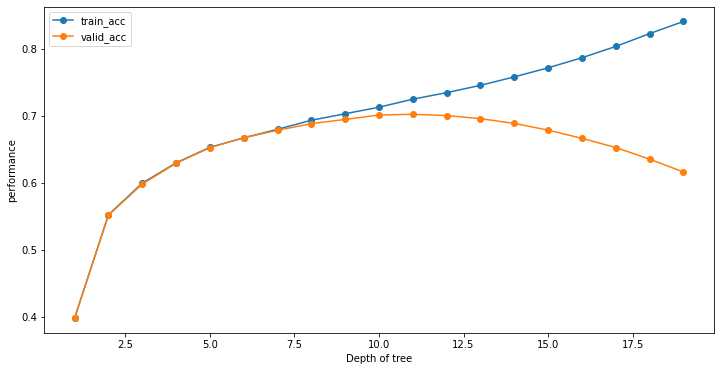

In [64]:
plt.figure(figsize=(12,6))
plt.plot(df['Max_depth'], df['train_scores'], marker='o', label='train_acc')
plt.plot(df['Max_depth'], df['test_score'], marker='o', label='valid_acc')
plt.xlabel('Depth of tree')
plt.ylabel('performance')
plt.legend()

* We'll also iterate through different values of min_samples_leaf, min_samples_split with respect to max_depth of analyze the best paarmeters for the model. 

In [65]:
train_scores = []
val_scores = []
for i in range(1,20):
    for j in range(1,6):
        for k in range(3,6):
            dt = DecisionTreeRegressor(random_state=10,max_depth=i,min_samples_leaf=j,min_samples_split=k)
            model = dt.fit(X_train,y_train)
            train_scores.append(model.score(X_train,y_train))
            val_scores.append(model.score(X_valid,y_valid))

In [122]:
max_depth=[]
min_samples_leaf=[]
min_samples_split=[]
for i in range(1,20):
    for j in range(1,6):
        for k in range(3,6):
            max_depth.append(i)
            min_samples_leaf.append(j)
            min_samples_split.append(k)    

In [123]:
df = pd.DataFrame({'max_depth':max_depth,'min_samples_leaf':min_samples_leaf,'min_samples_split':min_samples_split,'train_scores':train_scores,'test_score':val_scores})
df

,max_depth,min_samples_leaf,min_samples_split,train_scores,test_score
0,1,1,3,0.398156,0.399990
1,1,1,4,0.398156,0.399990
2,1,1,5,0.398156,0.399990
3,1,2,3,0.398156,0.399990
4,1,2,4,0.398156,0.399990
...,...,...,...,...,...
280,19,4,4,0.791867,0.665406
281,19,4,5,0.791867,0.665406
282,19,5,3,0.784100,0.672795
283,19,5,4,0.784100,0.672795


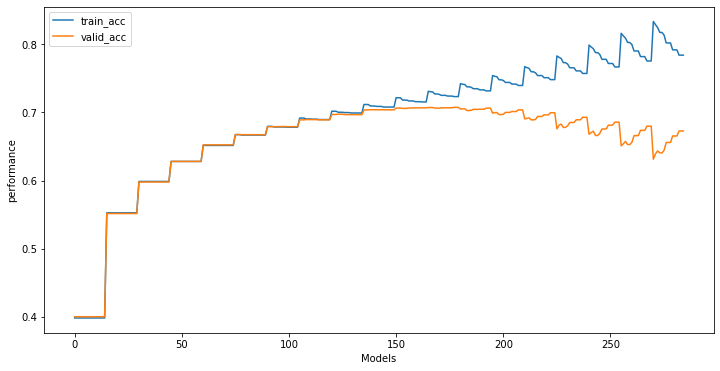

In [124]:
plt.figure(figsize=(12,6))
plt.plot( df['train_scores'], label='train_acc')
plt.plot( df['test_score'], label='valid_acc')
plt.xlabel('Models')
plt.ylabel('performance')
plt.legend()

In [ ]:
df[df['test_score'] == df['test_score'].max()]

* Final Model DT Model

In [232]:
dt_model = DecisionTreeRegressor(random_state=10,max_depth=12,min_samples_leaf=5,min_samples_split=3)

In [233]:
dt_model.fit(X_train, y_train)
training_accuracy = dt_model.score(X_train,y_train)
test_accuracy = dt_model.score(X_valid,y_valid)

In [234]:
training_accuracy,test_accuracy

(0.7251162222566574, 0.7018072894200215)

In [236]:
valid = dt_model.predict(X_valid)

In [237]:
len(y_valid),len(valid)

(206968, 206968)

In [239]:
d = pd.DataFrame({'Actual_Values':y_valid,'Fitted':valid})
error = mean_squared_error(y_valid,valid)
dt_rmse = np.sqrt(error)
dt_rmse

5.9533639605201465

### 4. KNN Model

In [240]:
df = data.drop(['dropoff_dow','dropoff_hour','dropoff_moy'],axis=1)

In [241]:
df = pd.get_dummies(data=df, columns=['pickup_dow'], drop_first=True)

In [242]:
X = df.drop('trip_duration',axis=1)
y = df['trip_duration']

In [243]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state = 42, test_size=0.30)

In [244]:
X_train.shape,X_valid.shape,y_train.shape,y_valid.shape

((482924, 11), (206968, 11), (482924,), (206968,))

In [248]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

knn_regressor = KNeighborsRegressor(n_neighbors=5)
knn_regressor.fit(X_train, y_train)

# Make predictions
y_pred = knn_regressor.predict(X_valid)

# Evaluate the model
mse = mean_squared_error(y_valid, y_pred)
knn_rmse = np.sqrt(mse)
knn_rmse

6.40514725156696

* optimizig the model by choosing right value of k using elbow method.

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

knn_regressor = KNeighborsRegressor(n_neighbors=250)
Knn_model = knn_regressor.fit(X_train, y_train)

# Make predictions
y_pred = Knn_model.predict(X_valid)

# Evaluate the model
mse = mean_squared_error(y_valid, y_pred)
print(f"Mean Squared Error: {mse}")

In [74]:
error = []
for i in range(1,250,20):
    knn_regressor = KNeighborsRegressor(n_neighbors=i)
    knn_regressor.fit(X_train, y_train)
    y_pred = knn_regressor.predict(X_valid)
    mse = mean_squared_error(y_valid, y_pred)
    error.append(mse)

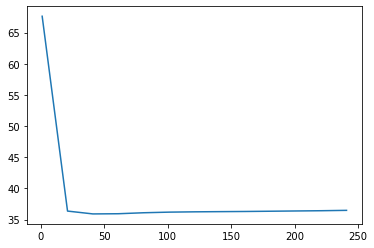

In [76]:
DF = pd.DataFrame({'K':range(1,250,20),'error':error})
plt.plot(DF['K'],DF['error'])

### 5. Kfolds Validation to Compare the models

In [255]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np

# Assuming X and y are your feature matrix and target variable
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)
# Create models
lr_model = LinearRegression()
dt_model = DecisionTreeRegressor(random_state=10,max_depth=12,min_samples_leaf=5,min_samples_split=3)

k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# Use neg_mean_squared_error for regression models
LR_model_error = -cross_val_score(lr_model, X, y, cv=kf, scoring=mse_scorer)

# Use accuracy for classification models
DT_model_error = -cross_val_score(dt_model, X, y, cv=kf, scoring=mse_scorer)


# Print or use the results as needed
print("Linear Regression Mean Squared Error:", LR_model_error)
print("Decision Tree Mean Squared Error:", DT_model_error)


Linear Regression Mean Squared Error: [48.66615919 49.6698158  48.32365764 47.82286285 49.53847687]
Decision Tree Mean Squared Error: [35.98680089 37.28151487 35.34505923 35.52452351 37.01668648]


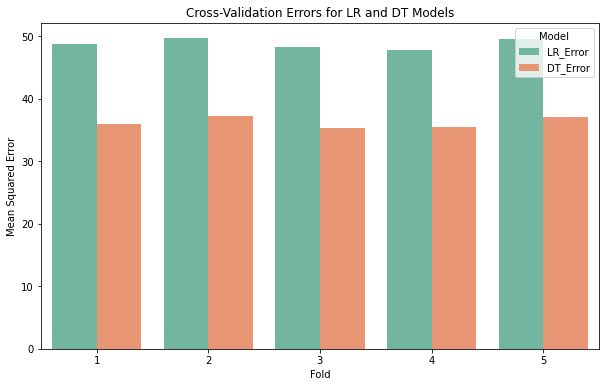

In [269]:
df = pd.DataFrame({'Fold': range(1, k_folds + 1),
                   'LR_Error': LR_model_error,
                   'DT_Error': DT_model_error})

# Melt the DataFrame for easy plotting with seaborn
df_melted = pd.melt(df, id_vars='Fold', var_name='Model', value_name='Error')

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Fold', y='Error', hue='Model', data=df_melted, palette='Set2')
plt.title('Cross-Validation Errors for LR and DT Models')
plt.xlabel('Fold')
plt.ylabel('Mean Squared Error')
plt.show()

* For k=3 folds both models are working well. Descision tree model produces less error compared to linear regression model. 

In [342]:
d['Residuals'] = d['Actual_Values'] - d['Fitted']

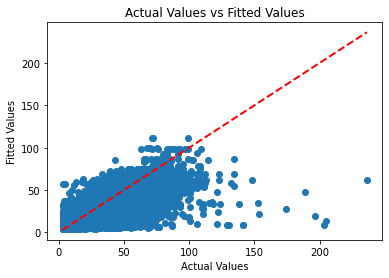

In [355]:
plt.scatter(d['Actual_Values'], d['Fitted'])
plt.plot([min(y_valid), max(y_valid)], [min(y_valid), max(y_valid)], linestyle='--', color='red', linewidth=2)
plt.title('Actual Values vs Fitted Values')
plt.xlabel('Actual Values')
plt.ylabel('Fitted Values')
plt.show()